📌 **Project Title**

E-Commerce Regional Revenue & Product Profitability Analysis

---

📖 **Business Problem**

The company is experiencing significant variation in regional sales performance and inconsistent revenue contribution across its product categories such as Laptops, Headphones, Smartwatches, and Accessories.

Due to the lack of structured analysis, the business is unable to:

* Identify high-performing regions
* Understand which products drive revenue vs volume
* Recognize high-value customers
* Optimize pricing and inventory decisions

This leads to inefficient marketing spend and missed revenue opportunities.

---

🎯 **Objective**

The goal of this analysis is to:

* Evaluate regional performance and identify underperforming markets
* Analyze product-level revenue contribution and demand patterns
* Identify high-value customers for targeted strategies
* Study monthly sales trends for seasonality insights
* Provide actionable recommendations to improve revenue by ~15%

---

🧠 **Analytical Approach**

This project follows a structured data analysis workflow:

* Data Cleaning & Validation
* Feature Engineering (Revenue Calculation)
* Exploratory Data Analysis (EDA)
* Customer & Product Segmentation
* Business Insight Generation

---

⚠️ **Data Challenges**

The dataset contains real-world issues such as:

* Missing values in price, quantity, and region
* Inconsistent categorical data (e.g., "Laptop", "laptop", "HEADPHONES")
* Duplicate records
* Extreme outliers (e.g., price = 1,000,000)
* Incorrect data types and formatting issues

These challenges are addressed before performing analysis to ensure accuracy.


In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\dolly\Desktop\ecommerce-analysis-project\data\messy_sales_data.csv")

# View first rows
df.head()

,order_id,order_date,product,region,customer_id,price,quantity
0,1000,2025-05-12,Keyboard,SOUth,519,196.129339,3.0
1,1001,2025-05-12,HEADPHONES,NaN,514,1018.432783,5.0
2,1002,2025-05-12,Laptop,north,506,942.494201,4.0
3,1003,2025-05-12,Laptop,north,501,NaN,1.0
4,1004,2025-05-12,laptop,NaN,507,1103.825846,5.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20010 entries, 0 to 20009
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     20010 non-null  int64  
 1   order_date   20010 non-null  object 
 2   product      20010 non-null  object 
 3   region       17191 non-null  object 
 4   customer_id  20010 non-null  int64  
 5   price        18009 non-null  float64
 6   quantity     19010 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 1.1+ MB


In [3]:
df.describe()

,order_id,customer_id,price,quantity
count,20010.000000,20010.000000,18009.000000,19010.000000
mean,11000.110395,509.984808,676.103941,2.995108
std,5773.132404,6.035104,7454.522431,1.410685
min,1000.000000,500.000000,50.016419,1.000000
25%,6001.250000,505.000000,332.596445,2.000000
50%,11000.500000,510.000000,613.365361,3.000000
75%,15999.750000,515.000000,909.822100,4.000000
max,20999.000000,520.000000,1000000.000000,5.000000


In [4]:
df.isnull().sum()

order_id          0
order_date        0
product           0
region         2819
customer_id       0
price          2001
quantity       1000
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(10)

In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

In [9]:
df["order_date"]

0       2025-05-12
1       2025-05-12
2       2025-05-12
3       2025-05-12
4       2025-05-12
           ...    
19995   2025-04-08
19996   2025-02-20
19997   2025-05-26
19998   2025-05-28
19999   2025-09-30
Name: order_date, Length: 20000, dtype: datetime64[ns]

In [10]:
df["product"] = df["product"].str.lower().str.strip()
df["region"] = df["region"].str.lower().str.strip()

In [11]:
df["product"] = df["product"].replace({
    "laptop": "Laptop",
    "headphones": "Headphones",
    "smartwatch": "Smartwatch",
    "monitor": "Monitor",
    "keyboard": "Keyboard"
})

df["region"] = df["region"].replace({
    "north": "North",
    "south": "South",
    "east": "East",
    "west": "West"
})

In [12]:
df.isnull().sum()

order_id          0
order_date        0
product           0
region         2819
customer_id       0
price          2000
quantity       1000
dtype: int64

In [13]:
# Fill numeric
df["price"] = df["price"].fillna(df["price"].median())
df["quantity"] = df["quantity"].fillna(df["quantity"].median())

# Fill region
df["region"] = df["region"].fillna("Unknown")

In [14]:
df

,order_id,order_date,product,region,customer_id,price,quantity
0,1000,2025-05-12,Keyboard,South,519,196.129339,3.0
1,1001,2025-05-12,Headphones,Unknown,514,1018.432783,5.0
2,1002,2025-05-12,Laptop,North,506,942.494201,4.0
3,1003,2025-05-12,Laptop,North,501,613.468730,1.0
4,1004,2025-05-12,Laptop,Unknown,507,1103.825846,5.0
...,...,...,...,...,...,...,...
19995,20995,2025-04-08,Headphones,Unknown,515,113.827235,5.0
19996,20996,2025-02-20,Smartwatch,Unknown,506,973.667857,4.0
19997,20997,2025-05-26,Keyboard,West,514,126.015112,4.0
19998,20998,2025-05-28,Headphones,North,518,613.468730,4.0


In [15]:
df["quantity"] = df["quantity"].astype(int)

In [16]:
df["price"] = df["price"].round(2)

In [17]:
df

,order_id,order_date,product,region,customer_id,price,quantity
0,1000,2025-05-12,Keyboard,South,519,196.13,3
1,1001,2025-05-12,Headphones,Unknown,514,1018.43,5
2,1002,2025-05-12,Laptop,North,506,942.49,4
3,1003,2025-05-12,Laptop,North,501,613.47,1
4,1004,2025-05-12,Laptop,Unknown,507,1103.83,5
...,...,...,...,...,...,...,...
19995,20995,2025-04-08,Headphones,Unknown,515,113.83,5
19996,20996,2025-02-20,Smartwatch,Unknown,506,973.67,4
19997,20997,2025-05-26,Keyboard,West,514,126.02,4
19998,20998,2025-05-28,Headphones,North,518,613.47,4


In [18]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify the outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

In [19]:
outliers

,order_id,order_date,product,region,customer_id,price,quantity
10,1010,2025-03-04,Laptop,South,506,1000000.0,1


In [20]:
# This modifies the original df immediately
df.drop(outliers.index, inplace=True)

In [22]:
df.reset_index(drop=True, inplace=True)

In [23]:
df

,order_id,order_date,product,region,customer_id,price,quantity
0,1000,2025-05-12,Keyboard,South,519,196.13,3
1,1001,2025-05-12,Headphones,Unknown,514,1018.43,5
2,1002,2025-05-12,Laptop,North,506,942.49,4
3,1003,2025-05-12,Laptop,North,501,613.47,1
4,1004,2025-05-12,Laptop,Unknown,507,1103.83,5
...,...,...,...,...,...,...,...
19994,20995,2025-04-08,Headphones,Unknown,515,113.83,5
19995,20996,2025-02-20,Smartwatch,Unknown,506,973.67,4
19996,20997,2025-05-26,Keyboard,West,514,126.02,4
19997,20998,2025-05-28,Headphones,North,518,613.47,4


In [24]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     19999 non-null  int64         
 1   order_date   19999 non-null  datetime64[ns]
 2   product      19999 non-null  object        
 3   region       19999 non-null  object        
 4   customer_id  19999 non-null  int64         
 5   price        19999 non-null  float64       
 6   quantity     19999 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 1.1+ MB


,order_id,order_date,customer_id,price,quantity
count,19999.000000,19999,19999.000000,19999.000000,19999.000000
mean,10999.999500,2025-05-31 08:01:07.683384064,509.985349,619.937362,2.995800
min,1000.000000,2025-01-01 00:00:00,500.000000,50.020000,1.000000
25%,6000.500000,2025-03-17 00:00:00,505.000000,362.340000,2.000000
50%,11000.000000,2025-05-31 00:00:00,510.000000,613.470000,3.000000
75%,15999.500000,2025-08-15 00:00:00,515.000000,877.595000,4.000000
max,20999.000000,2025-10-28 00:00:00,520.000000,1199.990000,5.000000
std,5773.359218,NaN,6.035344,316.097352,1.374799


In [25]:
df.head()

,order_id,order_date,product,region,customer_id,price,quantity
0,1000,2025-05-12,Keyboard,South,519,196.13,3
1,1001,2025-05-12,Headphones,Unknown,514,1018.43,5
2,1002,2025-05-12,Laptop,North,506,942.49,4
3,1003,2025-05-12,Laptop,North,501,613.47,1
4,1004,2025-05-12,Laptop,Unknown,507,1103.83,5


### Data Status: Cleaned

In [27]:
df["revenue"] = df["price"] * df["quantity"]

In [28]:
df["month_year"] = df["order_date"].dt.to_period("M")

In [29]:
df["month_name"] = df["order_date"].dt.month_name()
df["quarter"] = df["order_date"].dt.quarter

In [30]:
df.head()

,order_id,order_date,product,region,customer_id,price,quantity,revenue,month_year,month_name,quarter
0,1000,2025-05-12,Keyboard,South,519,196.13,3,588.39,2025-05,May,2
1,1001,2025-05-12,Headphones,Unknown,514,1018.43,5,5092.15,2025-05,May,2
2,1002,2025-05-12,Laptop,North,506,942.49,4,3769.96,2025-05,May,2
3,1003,2025-05-12,Laptop,North,501,613.47,1,613.47,2025-05,May,2
4,1004,2025-05-12,Laptop,Unknown,507,1103.83,5,5519.15,2025-05,May,2


In [31]:
customer_summary = df.groupby("customer_id").agg(
    total_orders=('order_id', 'count'),
    total_spent=('revenue', 'sum')
)

In [32]:
customer_summary.head()

,total_orders,total_spent
customer_id,,
500,948,1746598.65
501,948,1716692.50
502,961,1751464.56
503,930,1750977.10
504,974,1841907.46


In [33]:
customer_summary["segment"] = pd.cut(
    customer_summary["total_spent"],
    bins=[0, 5000, 20000, float("inf")],
    labels=["Low Value", "Medium Value", "High Value"]
)

In [34]:
df = df.merge(customer_summary, on="customer_id", how="left")

### 🔧 Feature Engineering

New features such as **Revenue**, **Month**, and **Customer Segments** were created to enable deeper business analysis.

These transformations helped convert raw transactional data into **meaningful analytical insights**, making it easier to identify trends, compare performance, and understand customer behavior.

In [36]:
df.head()

,order_id,order_date,product,region,customer_id,price,quantity,revenue,month_year,month_name,quarter,total_orders,total_spent,segment
0,1000,2025-05-12,Keyboard,South,519,196.13,3,588.39,2025-05,May,2,968,1801348.14,High Value
1,1001,2025-05-12,Headphones,Unknown,514,1018.43,5,5092.15,2025-05,May,2,1012,1807715.97,High Value
2,1002,2025-05-12,Laptop,North,506,942.49,4,3769.96,2025-05,May,2,968,1857117.28,High Value
3,1003,2025-05-12,Laptop,North,501,613.47,1,613.47,2025-05,May,2,948,1716692.50,High Value
4,1004,2025-05-12,Laptop,Unknown,507,1103.83,5,5519.15,2025-05,May,2,925,1702254.36,High Value


## Exploratory Data Analysis

In [40]:
#TOP PRODUCTS (Revenue Drivers)

top_products = (
    df.groupby("product")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_products

product
Headphones    10580325.23
Laptop        10308941.44
Keyboard       5536090.16
Monitor        5456460.85
Smartwatch     5310382.82
Name: revenue, dtype: float64

In [41]:
#TOP CUSTOMERS (High-Value Users)

top_customers = (
    df.groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

customer_id
509    1889373.52
506    1857117.28
504    1841907.46
516    1818375.70
510    1816831.67
513    1816558.56
514    1807715.97
519    1801348.14
515    1783010.34
505    1766477.70
Name: revenue, dtype: float64

In [42]:
#REGION PERFORMANCE

region_perf = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

region_perf

region
South      10782664.39
North      10591231.32
East        5513275.90
West        5155754.63
Unknown     5149274.26
Name: revenue, dtype: float64

In [43]:
#MONTHLY TREND

monthly = (
    df.groupby("month_name")["revenue"]
    .sum()
)

monthly

month_name
April        3805132.21
August       3743345.89
February     3563937.40
January      3894830.48
July         3776583.23
June         3562729.78
March        3636048.40
May          3945580.85
October      3452358.79
September    3811653.47
Name: revenue, dtype: float64

In [48]:
#Fix Order

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly = monthly.reindex(month_order)
monthly

month_name
January      3894830.48
February     3563937.40
March        3636048.40
April        3805132.21
May          3945580.85
June         3562729.78
July         3776583.23
August       3743345.89
September    3811653.47
October      3452358.79
November            NaN
December            NaN
Name: revenue, dtype: float64

In [49]:
#CUSTOMER BEHAVIOR
customer_behavior = df.groupby("customer_id").agg({
    "order_id": "count",
    "revenue": "sum"
}).rename(columns={
    "order_id": "total_orders",
    "revenue": "total_spent"
})

customer_behavior

,total_orders,total_spent
customer_id,,
500,948,1746598.65
501,948,1716692.50
502,961,1751464.56
503,930,1750977.10
504,974,1841907.46
505,958,1766477.70
506,968,1857117.28
507,925,1702254.36
508,950,1762563.94


In [51]:
#CUSTOMER SEGMENT DISTRIBUTION
customer_summary["segment"].value_counts()

segment
High Value      21
Low Value        0
Medium Value     0
Name: count, dtype: int64

In [65]:
#REVENUE BY CUSTOMER SEGMENT
segment_revenue = customer_summary.groupby("segment", observed=True)["total_spent"].sum()
segment_revenue

segment
High Value    37192200.5
Name: total_spent, dtype: float64

In [68]:
#PRODUCT: VOLUME vs REVENUE ANALYSIS

product_analysis = df.groupby("product").agg({
    "quantity": "sum",
    "revenue": "sum"
}).sort_values(by="revenue", ascending=False)

product_analysis

,quantity,revenue
product,,
Headphones,16987,10580325.23
Laptop,16839,10308941.44
Keyboard,8887,5536090.16
Monitor,8718,5456460.85
Smartwatch,8482,5310382.82


In [69]:
#AVERAGE ORDER VALUE (AOV)
aov = round(df["revenue"].sum() / df["order_id"].nunique(), 2)
aov

np.float64(1859.7)

In [71]:
#PRICE vs QUANTITY (PRICING STRATEGY)

price_quantity = df.groupby("product").agg({
    "price": "mean",
    "quantity": "mean"
})

# Round price and convert quantity to int
price_quantity["price"] = price_quantity["price"].round(2)
price_quantity["quantity"] = price_quantity["quantity"].astype(int)

price_quantity

,price,quantity
product,,
Headphones,621.73,2
Keyboard,624.49,3
Laptop,611.55,2
Monitor,622.41,3
Smartwatch,625.82,3


In [72]:
#REPEAT vs NEW CUSTOMERS (SIMPLE LOGIC)

repeat_customers = customer_summary[customer_summary["total_orders"] > 1].shape[0]
total_customers = customer_summary.shape[0]

repeat_customers, total_customers

(21, 21)

#### Advanced analysis was performed to segment customers, evaluate product performance based on revenue and volume, and assess pricing impact on demand. These insights help in identifying high-value customers and optimizing pricing strategies

### 📊 Visualization

In [73]:
import matplotlib.pyplot as plt

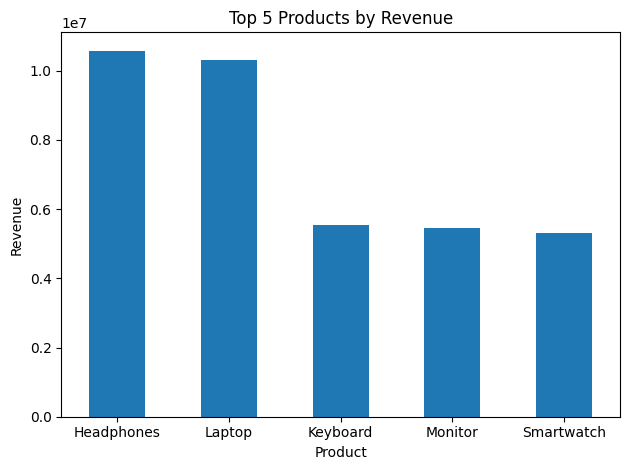

In [75]:
#TOP PRODUCTS (BAR CHART)

top_products.head(5).plot(kind="bar")
plt.title("Top 5 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

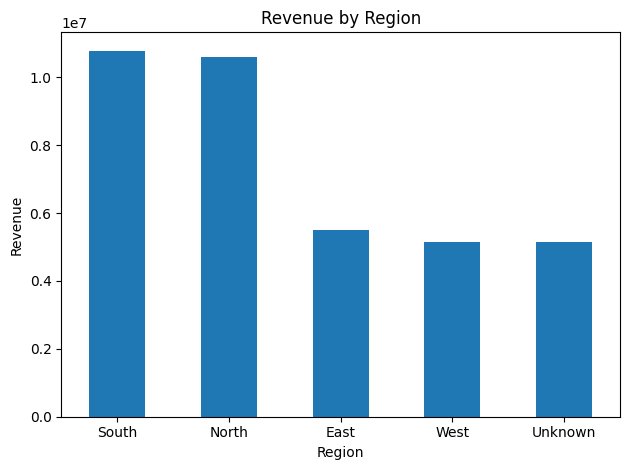

In [77]:
#REGION PERFORMANCE

region_perf.plot(kind="bar")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

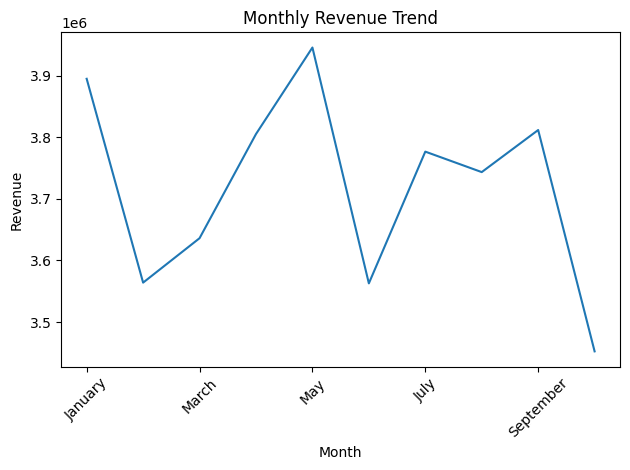

In [80]:
#MONTHLY TREND (LINE CHART)

monthly.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

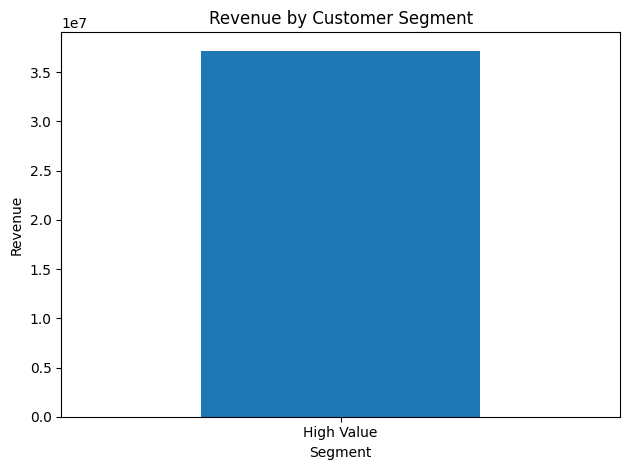

In [81]:
#CUSTOMER SEGMENT

segment_revenue.plot(kind="bar")
plt.title("Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Visualizations were created to clearly communicate key insights such as **product performance**, **regional contribution**, and **seasonal trends**. These charts help in quickly identifying patterns and supporting data-driven business decisions.

### 📌 Key Business Insights

**1. Revenue is concentrated in a few products**  

Headphones (₹1.06 Cr approx) and Laptops (₹1.03 Cr approx) together contribute the majority of total revenue, while other products like Smartwatch (₹53L approx) and Monitor (₹54L approx) lag behind.  

This shows the business is highly dependent on two product categories, which creates risk if demand drops.  


**2. South and North regions dominate performance**  

South (₹1.07 Cr approx) and North (₹1.05 Cr approx) generate almost double the revenue compared to East (₹55L approx) and West (₹51L approx).  

This confirms strong regional imbalance, meaning marketing and inventory are not optimized across regions.  


**3. Significant revenue loss due to "Unknown" region**  

The "Unknown" category alone contributes ₹51L approx revenue.  

This indicates data quality issues impacting decision-making, as a large portion of revenue cannot be attributed to any region.  


**4. Revenue is stable across months with slight peak in May**  

Revenue remains relatively consistent (₹35L to ₹39L monthly), with the highest in May (₹39.4L approx).  

This suggests no strong seasonality, but slight peaks can be targeted for promotions.  


**5. Customer base is highly concentrated but valuable**  

All 21 customers fall under the High Value segment, each contributing ₹16L to ₹18L approx in revenue.  

This shows the business depends on a small number of high-value customers, indicating strong revenue but high dependency risk.  


**6. High repeat customer behavior**  

All customers are repeat buyers (21 out of 21), with 900 to 1000 orders each.  

This indicates strong customer retention, which is positive for long-term stability.  


**7. Product pricing is consistent across categories**  

Average price across products is similar (₹610 to ₹625 approx), and average quantity per order is 2 to 3 units.  

This suggests no clear pricing differentiation, meaning revenue differences are driven more by demand than pricing strategy.  


**8. Average Order Value (AOV) is strong**  

The AOV is approximately ₹1859 per order, indicating healthy transaction size.  

This reflects good customer spending behavior, but also highlights opportunity to increase AOV through bundling or upselling.

**📌 Business Recommendations**

**1. Expand focus on underperforming regions (East & West)**  

With revenue around ₹51–55L compared to ₹1Cr+ in South and North, targeted marketing campaigns and better inventory distribution in these regions can unlock growth.  


**2. Reduce dependency on top 2 products (Headphones & Laptops)**  

Since these contribute the majority of revenue (₹2.09 Cr approx combined), the business should promote categories like Smartwatch and Monitor through bundling or discounts to diversify revenue streams.  


**3. Improve data quality for regional analysis**  

The "Unknown" region contributes ₹51L approx revenue, which limits decision-making. Ensuring proper region tracking can significantly improve strategic planning.  


**4. Leverage high-value repeat customers (Retention Strategy)**  

All customers are repeat and high-value (₹16L to ₹18L each). Introducing loyalty programs, exclusive offers, or early access deals can further increase customer lifetime value.  


**5. Introduce pricing or bundle strategies to increase AOV**  

Current AOV is ₹1859 approx. Since pricing is similar across products (₹610 to ₹625), combining products such as Laptop with Accessories can increase order value.  


**6. Capitalize on consistent monthly demand with targeted campaigns**  

Revenue is stable (₹35L to ₹39L monthly), with slight peaks in May. Running promotions during peak months can further boost revenue without major risk.  

In [87]:
df.to_csv(r"C:\Users\dolly\Desktop\ecommerce-analysis-project\outputs\cleaned_data.csv", index=False)